# Ensemble Regression Method


In [1]:
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing()
import seaborn as sns


#Creating feature and target arrays
X, y = california_housing.data, california_housing.target
columns = california_housing.feature_names

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=42)

## Random forest


 Los parámetros del RandomForestRegressor que se usaron en el GridSearchCV:

n_estimators: Este parámetro define el número de árboles en el bosque (el número de modelos base). Un mayor número de estimadores generalmente mejora el rendimiento del modelo, pero también aumenta el tiempo de entrenamiento y la complejidad computacional. Los valores explorados fueron [5, 10, 100, 200].

criterion: Es la función para medir la calidad de una división. Para regresión, el 'error cuadrático medio' ('mse') es una opción común y en este caso fue el único valor especificado.

min_samples_leaf: Este parámetro especifica el número mínimo de muestras requeridas para estar en un nodo hoja. Si un split resulta en que una de las hojas tiene menos muestras que este umbral, el split no se realiza. Un valor más alto puede reducir el sobreajuste. Los valores explorados fueron [0.03, 0.05, 0.1, 0.3].

random_state: Este parámetro se usa para controlar la aleatoriedad del modelo. Al establecer un valor fijo (en este caso, 42), se asegura que los resultados sean reproducibles. Es decir, si se ejecuta el código varias veces con el mismo random_state, siempre se obtendrán los mismos resultados aleatorios.

In [2]:
#DEFINE YOUR REGRESSOR and THE PARAMETERS GRID
from sklearn.ensemble import RandomForestRegressor
import numpy as np

regressor = RandomForestRegressor()
parameters = {"n_estimators":[5,10,100,200], "criterion": ['squared_error'],
              "min_samples_leaf": [0.1,0.3], "random_state" : [42]}

#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(regressor, parameters, cv=3) #with no params it reduces to a CV

gs = gs.fit(X_train,y_train)

#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))
means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

#Returns the coefficient of determination R^2 of the prediction.
#Explained variance score: 1 is perfect prediction
gs.score(X_test, y_test)

***GRIDSEARCH RESULTS***
Best score: 0.473820 using {'criterion': 'squared_error', 'min_samples_leaf': 0.1, 'n_estimators': 200, 'random_state': 42}
0.461560 (0.017254) with: {'criterion': 'squared_error', 'min_samples_leaf': 0.1, 'n_estimators': 5, 'random_state': 42}
0.472693 (0.015408) with: {'criterion': 'squared_error', 'min_samples_leaf': 0.1, 'n_estimators': 10, 'random_state': 42}
0.473413 (0.010331) with: {'criterion': 'squared_error', 'min_samples_leaf': 0.1, 'n_estimators': 100, 'random_state': 42}
0.473820 (0.009140) with: {'criterion': 'squared_error', 'min_samples_leaf': 0.1, 'n_estimators': 200, 'random_state': 42}
0.270327 (0.001385) with: {'criterion': 'squared_error', 'min_samples_leaf': 0.3, 'n_estimators': 5, 'random_state': 42}
0.272848 (0.004803) with: {'criterion': 'squared_error', 'min_samples_leaf': 0.3, 'n_estimators': 10, 'random_state': 42}
0.273332 (0.005099) with: {'criterion': 'squared_error', 'min_samples_leaf': 0.3, 'n_estimators': 100, 'random_state': 

0.46013388012150336

In [3]:
from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train, gs.predict(X_train)))
print("MSE train: ",metrics.mean_squared_error(y_train, gs.predict(X_train)))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, gs.predict(X_train))))
print("r2: ",np.sqrt(metrics.r2_score(y_train, gs.predict(X_train))))

print("MAE test: ", metrics.mean_absolute_error(y_test, gs.predict(X_test)))
print("MSE test: ",metrics.mean_squared_error(y_test, gs.predict(X_test)))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, gs.predict(X_test))))
print("r2: ",np.sqrt(metrics.r2_score(y_test, gs.predict(X_test))))

MAE train:  0.6352512174410567
MSE train:  0.7044487493893954
RMSE train:  0.839314452031773
r2:  0.6886019728831885
MAE test:  0.6400102541674896
MSE test:  0.708595935190374
RMSE test:  0.8417814058236105
r2:  0.6783316888672557


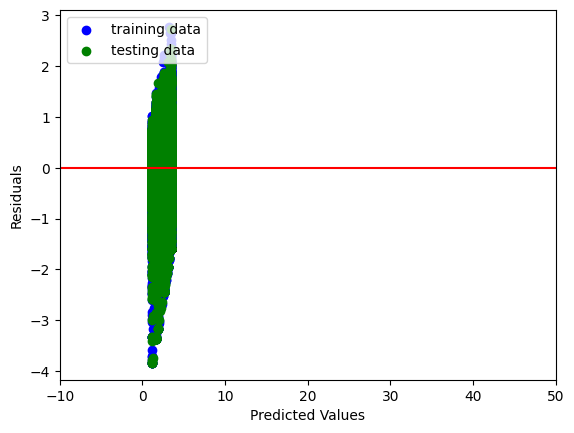

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.scatter(gs.predict(X_train),gs.predict(X_train)-y_train, c="b", label="training data")
plt.scatter(gs.predict(X_test),gs.predict(X_test)-y_test, c="g", label="testing data")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=-10, xmax=50, color="r")
plt.xlim([-10,50])
plt.show()

In [5]:
from sklearn import tree
r = tree.export_text(gs.best_estimator_.estimators_[40],feature_names=columns, max_depth=3)
print(r)

|--- MedInc <= 5.03
|   |--- MedInc <= 3.05
|   |   |--- AveRooms <= 4.36
|   |   |   |--- value: [1.61]
|   |   |--- AveRooms >  4.36
|   |   |   |--- value: [1.16]
|   |--- MedInc >  3.05
|   |   |--- AveOccup <= 2.62
|   |   |   |--- value: [2.51]
|   |   |--- AveOccup >  2.62
|   |   |   |--- value: [1.82]
|--- MedInc >  5.03
|   |--- value: [3.31]



In [6]:
# We can export as a figure but we must install graphviz https://graphviz.gitlab.io/download/

# Install graphviz in the current Jupyter kernel
!apt-get install graphviz
!pip install graphviz

from sklearn import tree
tree.export_graphviz(gs.best_estimator_.estimators_[0], out_file='tree_from_forest.dot',feature_names=columns,max_depth=4)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.8 MB/s eta 0:00:00


In [7]:
!dot -Tpng tree_from_forest.dot -o tree_from_forest.png -Gdpi=600

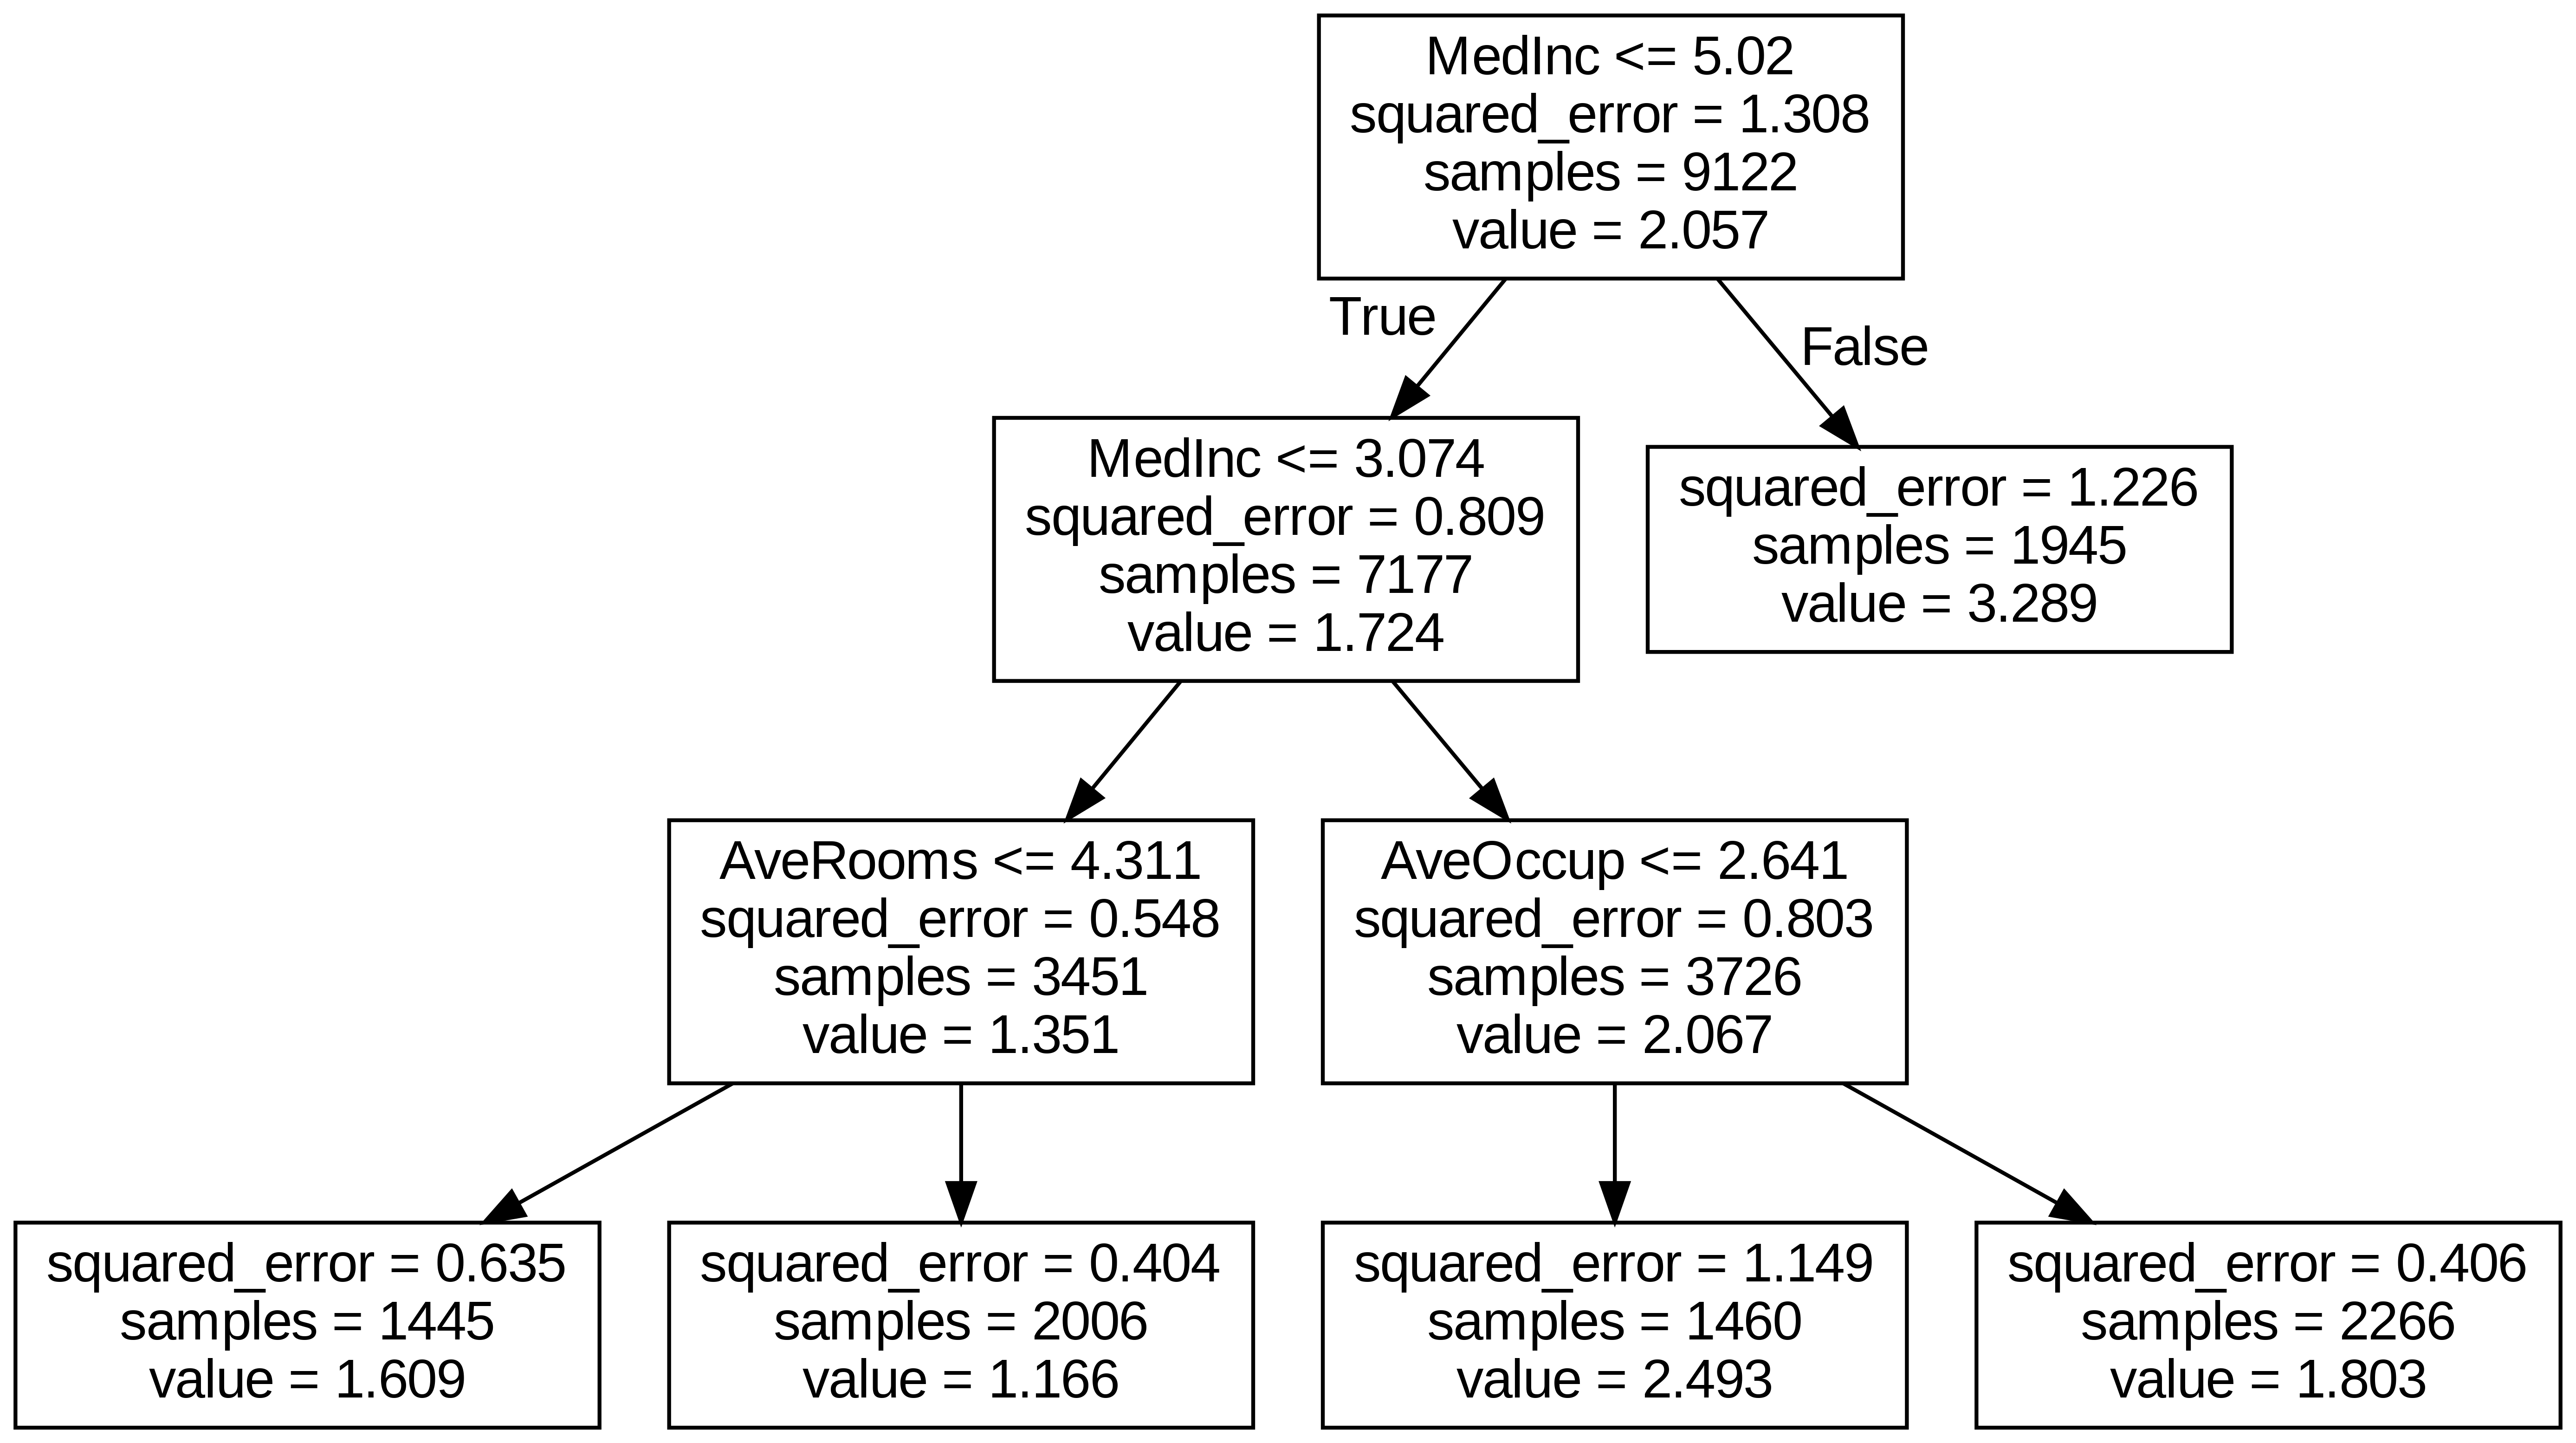

In [8]:
from IPython.display import Image
Image(filename = 'tree_from_forest.png')

/tmp/ipykernel_664/1855461064.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columns, y=gs.best_estimator_.feature_importances_, palette="Blues_d")


<Axes: >

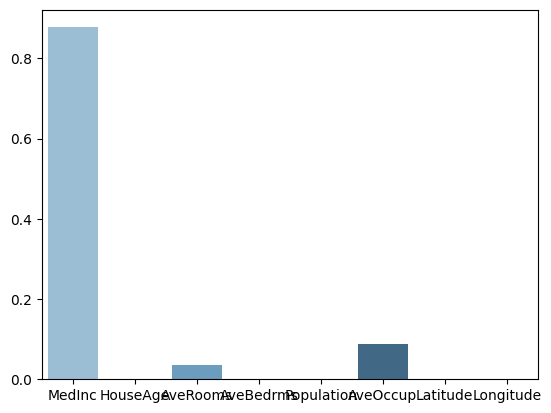

In [9]:
sns.barplot(x=columns, y=gs.best_estimator_.feature_importances_, palette="Blues_d")

## AdaBoost

https://share.google/daWGgu1MlmSjXNiUn

In [ ]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor


base1=SVR(kernel='linear')
base2=DecisionTreeRegressor(max_depth=3)

regressor = AdaBoostRegressor()
parameters = {"n_estimators":[10,50], "estimator": [base1,base2],
              "learning_rate":[0.5,1.0], "random_state" : [4]}

#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(regressor, parameters, cv=3) #with no params it reduces to a CV

gs = gs.fit(X_train,y_train)

#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))
means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

#Returns the coefficient of determination R^2 of the prediction.
#Explained variance score: 1 is perfect prediction
gs.score(X_test, y_test)

In [ ]:
y_train_pred=gs.predict(X_train)
y_pred=gs.predict(X_test)


In [ ]:
from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train, y_train_pred))
print("MSE train: ",metrics.mean_squared_error(y_train, y_train_pred))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))
print("r2: ",np.sqrt(metrics.r2_score(y_train, y_train_pred)))

print("MAE test: ", metrics.mean_absolute_error(y_test,y_pred))
print("MSE test: ",metrics.mean_squared_error(y_test, y_pred))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("r2: ",np.sqrt(metrics.r2_score(y_test, y_pred)))

MAE train:  2.0214626619841276
MSE train:  6.30461219741418
RMSE train:  2.510898683223634
r2:  0.9501390183752204
MAE test:  2.206059896439992
MSE test:  7.6570077376527745
RMSE test:  2.767129873651176
r2:  0.9242150539864702


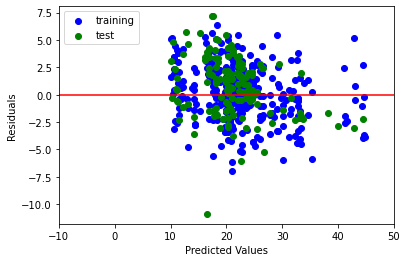

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.scatter(gs.predict(X_train),y_train_pred-y_train, c="b", label="training")
plt.scatter(gs.predict(X_test),y_pred-y_test, c="g", label="test")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=-10, xmax=50, color="r")
plt.xlim([-10,50])
plt.show()

# Gradient Boosting

$$ \hat{y_i} = F_M(x_i) = \sum_{m=1}^{M} h_m(x_i) $$
$$ F_m(x) = F_{m-1}(x) + h_m(x)$$
$$ h_m =  \arg\min_{h} L_m = \arg\min_{h} \sum_{i=1}^{n}
l(y_i, F_{m-1}(x_i) + h(x_i))$$

$$ F_m(x) = F_{m-1}(x) + \nu h_m(x)$$



## Pedir explicación de gradient boosting

https://share.google/MkO2h08L5I75R1kkV

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

regressor = GradientBoostingRegressor() # base_estimator=DecisionTreeRegressor(max_depth=3)
parameters = {"n_estimators":[20,50,70,100,200], "learning_rate":[0.1, 0.5,1,2],
              "random_state" : [0] ,
             "max_depth":[1,2]}

#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(regressor, parameters, cv=3)

gs = gs.fit(X_train,y_train)


#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))
means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

#Returns the coefficient of determination R^2 of the prediction.
#Explained variance score: 1 is perfect prediction
gs.score(X_test, y_test)

***GRIDSEARCH RESULTS***
Best score: 0.859229 using {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'random_state': 0}
0.670644 (0.015695) with: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 20, 'random_state': 0}
0.809183 (0.017359) with: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 50, 'random_state': 0}
0.822335 (0.016185) with: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 70, 'random_state': 0}
0.829915 (0.015525) with: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 100, 'random_state': 0}
0.839042 (0.015164) with: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 200, 'random_state': 0}
0.800103 (0.017997) with: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 20, 'random_state': 0}
0.845636 (0.017315) with: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50, 'random_state': 0}
0.852033 (0.016396) with: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 70, 'random_state': 0}
0.856134 (0.017180) with: {'learnin

0.8794916585909461

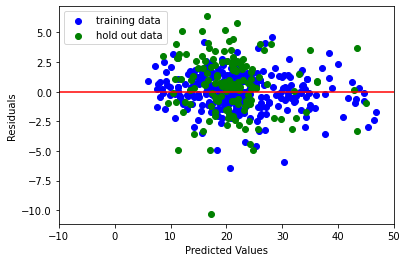

In [ ]:

%matplotlib inline
import matplotlib.pyplot as plt
plt.scatter(gs.predict(X_train),gs.predict(X_train)-y_train, c="b", label="training data")
plt.scatter(gs.predict(X_test),gs.predict(X_test)-y_test, c="g", label="hold out data")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=-10, xmax=50, color="r")
plt.xlim([-10,50])
plt.show()

In [ ]:
from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train, gs.predict(X_train)))
print("MSE train: ",metrics.mean_squared_error(y_train, gs.predict(X_train)))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, gs.predict(X_train))))
print("r2: ",np.sqrt(metrics.r2_score(y_train, gs.predict(X_train))))

print("MAE test: ", metrics.mean_absolute_error(y_test, gs.predict(X_test)))
print("MSE test: ",metrics.mean_squared_error(y_test, gs.predict(X_test)))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, gs.predict(X_test))))
print("r2: ",np.sqrt(metrics.r2_score(y_test, gs.predict(X_test))))

MAE train:  1.126445503009674
MSE train:  2.2074713574197884
RMSE train:  1.4857561567834032
r2:  0.9828297081061426
MAE test:  1.9809660149189192
MSE test:  6.327609094220778
RMSE test:  2.5154739303401215
r2:  0.9378121659431307
